In [2]:
#Importing dependencies 

import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array


2025-08-11 14:40:25.964688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-11 14:40:25.983249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754937626.002298 2621214 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754937626.007744 2621214 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754937626.021823 2621214 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
#Joining pandas dfs (train and test)

test_df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/PFED5/test_cnn.csv")
train_df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/PFED5/train_cnn.csv")

df = pd.concat([train_df, test_df], axis = 0)
df


,UPDRS_score,main_frame,description_clench the teeth,description_frown,description_sitting at rest,description_smile,description_squeeze eyes tightly
0,4,frames/001/12-104704_0/img_00032.jpg,0.0,0.0,1.0,0.0,0.0
1,2,frames/001/12-104704_1/img_00037.jpg,0.0,0.0,0.0,1.0,0.0
2,1,frames/001/12-104704_2/img_00038.jpg,0.0,1.0,0.0,0.0,0.0
3,1,frames/001/12-104704_3/img_00057.jpg,0.0,0.0,0.0,0.0,1.0
4,2,frames/001/12-104704_4/img_00046.jpg,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
759,2,frames/063/16-002607_0/img_00016.jpg,0.0,0.0,1.0,0.0,0.0
760,3,frames/063/16-002607_1/img_00063.jpg,0.0,0.0,0.0,1.0,0.0
761,4,frames/063/16-002607_2/img_00054.jpg,0.0,1.0,0.0,0.0,0.0
762,2,frames/063/16-002607_3/img_00048.jpg,0.0,0.0,0.0,0.0,1.0


In [4]:
#Checking if data is balanced

df["UPDRS_score"].value_counts()

UPDRS_score
1    891
2    766
0    547
3    512
4     95
Name: count, dtype: int64

In [5]:
#Scale numerical label
df["UPDRS_score"] = df["UPDRS_score"] / 4

In [6]:
#Checking if data is balanced after scaling

df["UPDRS_score"].value_counts()

UPDRS_score
0.25    891
0.50    766
0.00    547
0.75    512
1.00     95
Name: count, dtype: int64

In [7]:
#Running stastical test to see how descriptions are correlated to the lable

#Importing the packages
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression

#description columsn from the df dataset
description_cols = [col for col in df.columns if col.startswith("description")]

#Extracting the individual values
X_desc = df[description_cols].values
y_updrs = df["UPDRS_score"].values

#Fiding correlation
f_scores, p_values = f_regression(X_desc, y_updrs)

for label, score, p in zip(description_cols, f_scores, p_values):
    print(label, "F-score", score, "p-value" , p)

description_clench the teeth F-score 9.50567502594437 p-value 0.002068270205943871
description_frown F-score 0.20029947552970845 p-value 0.6545137361734168
description_sitting at rest F-score 0.13053411135813753 p-value 0.7179060666698132
description_smile F-score 0.13539429377857662 p-value 0.7129310554699444
description_squeeze eyes tightly F-score 11.272017586387054 p-value 0.0007973204715189662


In [8]:
#Dropping features based on the f-score and p-value

df = df.drop (columns = ["description_sitting at rest", "description_squeeze eyes tightly" ,"description_frown", "description_sitting at rest", "description_smile"])

In [9]:
df

,UPDRS_score,main_frame,description_clench the teeth
0,1.00,frames/001/12-104704_0/img_00032.jpg,0.0
1,0.50,frames/001/12-104704_1/img_00037.jpg,0.0
2,0.25,frames/001/12-104704_2/img_00038.jpg,0.0
3,0.25,frames/001/12-104704_3/img_00057.jpg,0.0
4,0.50,frames/001/12-104704_4/img_00046.jpg,1.0
...,...,...,...
759,0.50,frames/063/16-002607_0/img_00016.jpg,0.0
760,0.75,frames/063/16-002607_1/img_00063.jpg,0.0
761,1.00,frames/063/16-002607_2/img_00054.jpg,0.0
762,0.50,frames/063/16-002607_3/img_00048.jpg,0.0


In [10]:
df

,UPDRS_score,main_frame,description_clench the teeth
0,1.00,frames/001/12-104704_0/img_00032.jpg,0.0
1,0.50,frames/001/12-104704_1/img_00037.jpg,0.0
2,0.25,frames/001/12-104704_2/img_00038.jpg,0.0
3,0.25,frames/001/12-104704_3/img_00057.jpg,0.0
4,0.50,frames/001/12-104704_4/img_00046.jpg,1.0
...,...,...,...
759,0.50,frames/063/16-002607_0/img_00016.jpg,0.0
760,0.75,frames/063/16-002607_1/img_00063.jpg,0.0
761,1.00,frames/063/16-002607_2/img_00054.jpg,0.0
762,0.50,frames/063/16-002607_3/img_00048.jpg,0.0


In [11]:
df["UPDRS_score"].value_counts()

UPDRS_score
0.25    891
0.50    766
0.00    547
0.75    512
1.00     95
Name: count, dtype: int64

In [12]:
#Load and preprocess image dataset

#Create a method pipeline for loading images
def load_data(df, base_dir, img_size=(224, 224)):
    #creating images and the corresponding labels
    images = []
    labels = []
    
    # iterating through each trow
    for _, row in df.iterrows():
        #graping the path of the image in my datafra,e
        img_path = os.path.join(base_dir, row["main_frame"])
        #scale the image 
        try:
            img = load_img(img_path, color_mode="grayscale", target_size=img_size)
            image = img_to_array(img) / 255.0
            images.append(image)

            # Multi-output labels ( 2 regression targets ), the UPDRS score and the description
            labels.append([    
                row["UPDRS_score"],
                

            ])
        except Exception as e:
            print("Error loading image:", img_path)
    
    #Return the labels and the features

    X = np.array(images)
    y = np.array(labels, dtype=np.float32)
    return X, y


In [13]:
df

,UPDRS_score,main_frame,description_clench the teeth
0,1.00,frames/001/12-104704_0/img_00032.jpg,0.0
1,0.50,frames/001/12-104704_1/img_00037.jpg,0.0
2,0.25,frames/001/12-104704_2/img_00038.jpg,0.0
3,0.25,frames/001/12-104704_3/img_00057.jpg,0.0
4,0.50,frames/001/12-104704_4/img_00046.jpg,1.0
...,...,...,...
759,0.50,frames/063/16-002607_0/img_00016.jpg,0.0
760,0.75,frames/063/16-002607_1/img_00063.jpg,0.0
761,1.00,frames/063/16-002607_2/img_00054.jpg,0.0
762,0.50,frames/063/16-002607_3/img_00048.jpg,0.0


In [14]:
#Splitting dataset 
from sklearn.model_selection import train_test_split

base_dir = "/users/imbahndu/Desktop/Columbia DBM/PFED5/" 

X, y = load_data (df, base_dir = base_dir)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [15]:
# Assuming you already split your data into X_train, X_test, y_train, y_test

# Round UPDRS_score back to integer classes for y_train only
y_train_classes = np.round(y_train[:, 0] * 4).astype(int)  

from sklearn.utils import class_weight

# Compute class weights from training labels only
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_classes),
    y=y_train_classes
)

class_weights_dict = dict(enumerate(class_weights))


# Create sample weights array for each sample in y_train
sample_weights = np.array([class_weights_dict[c] for c in y_train_classes])

print(class_weights_dict)

{0: 1.0035714285714286, 1: 0.6288111888111888, 2: 0.7443708609271523, 3: 1.124, 4: 5.550617283950618}


In [16]:
#Create convulation layers and using data augmentation for images to standardize everything

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomContrast(0.1)])

#Building up the layers

cnn_model = keras.Sequential()

#Building 1st layer
input_layer = keras.layers.InputLayer(input_shape = (224, 224, 1))
cnn_model.add(input_layer)
cnn_model.add(data_augmentation)

#Building 2nd layer
hidden_layer_1 = keras.layers.Conv2D(filters = 16, kernel_size =3 , padding = "same")
batchNorm_1 = keras.layers.BatchNormalization()
relu_1 = keras.layers.ReLU()
cnn_model.add(hidden_layer_1)
cnn_model.add(batchNorm_1)
cnn_model.add(relu_1)

#Pooling layer 
cnn_model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

#Building 3rd layer
hidden_layer_2 = keras.layers.Conv2D(filters = 32, kernel_size = 3, padding = "same")
batchNorm_2 = keras.layers.BatchNormalization()
relu_2 = keras.layers.ReLU()
cnn_model.add(hidden_layer_2)
cnn_model.add(batchNorm_2)
cnn_model.add(relu_2)

#Building 4th layer
hidden_layer_3 = keras.layers.Conv2D(filters = 64, kernel_size = 3, padding = "same")
batchNorm_3 = keras.layers.BatchNormalization()
relu_3 = keras.layers.ReLU()
cnn_model.add(hidden_layer_3)
cnn_model.add(batchNorm_3)
cnn_model.add(relu_3)

#Pooling layer
cnn_model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

#Building 5th layer
hidden_layer_4 = keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = "same")
batchNorm_4 = keras.layers.BatchNormalization()
relu_4 = keras.layers.ReLU()
cnn_model.add(hidden_layer_4)
cnn_model.add(batchNorm_4)
cnn_model.add(relu_4)

#Building 6th layer
hidden_layer_6 = keras.layers.Conv2D(filters = 256, kernel_size = 3, padding = "same")
batchNorm_6 = keras.layers.BatchNormalization()
relu_6 = keras.layers.ReLU()
cnn_model.add(hidden_layer_6)
cnn_model.add(batchNorm_6)
cnn_model.add(relu_6)

#Building 7th layer
hidden_layer_7 = keras.layers.Conv2D(filters = 512, kernel_size = 3, padding = "same")
batchNorm_7 = keras.layers.BatchNormalization()
relu_7 = keras.layers.ReLU()
cnn_model.add(hidden_layer_7)
cnn_model.add(batchNorm_7)
cnn_model.add(relu_7)


#Adding pooling layer for translation invariance
pooling_layer = keras.layers.GlobalAveragePooling2D()
cnn_model.add(pooling_layer)

#Regularization
cnn_model.add(keras.layers.Dropout(0.5))

#Adding output layer
output_layer = keras.layers.Dense(1, activation="linear")
cnn_model.add(output_layer)


#Summary 
cnn_model.summary()

2025-08-11 14:40:40.113132: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             

 Total params: 1,577,025 (6.02 MB)

 Trainable params: 1,575,009 (6.01 MB)

 Non-trainable params: 2,016 (7.88 KB)

In [ ]:
#compiling the model with loss_fn and optimizer


cnn_model.compile(optimizer = "adam", loss = "mae", metrics = ["mse", "mae"])

NameError: name 'MeanAbsoluteError' is not defined

In [ ]:
#fitting the model
num_epochs = 10
history = cnn_model.fit(X_train, y_train, epochs=num_epochs, validation_split=0.2, sample_weight=sample_weights)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.7207 - mae: 0.5772 - mse: 0.5231 - val_loss: 0.2622 - val_mae: 0.3331 - val_mse: 0.1431
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.5096 - mae: 0.5106 - mse: 0.4854 - val_loss: 0.2368 - val_mae: 0.2892 - val_mse: 0.1106
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.5670 - mae: 0.5104 - mse: 0.4239 - val_loss: 0.2042 - val_mae: 0.2292 - val_mse: 0.0760
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - loss: 0.5482 - mae: 0.4967 - mse: 0.3794 - val_loss: 0.1957 - val_mae: 0.1968 - val_mse: 0.0517
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 66s 5s/step - loss: 0.4885 - mae: 0.4741 - mse: 0.3657 - val_loss: 0.2279 - val_mae: 0.2726 - val_mse: 0.1021
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step - loss: 0.4849 - mae: 0.4424 - mse: 0.3162 - val_loss: 0.2048 - val_mae: 0.2303 - val_mse: 0.0772
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - loss: 0.4620 - mae: 0.4514 - mse: 0.3167 - val_loss: 0.2374 

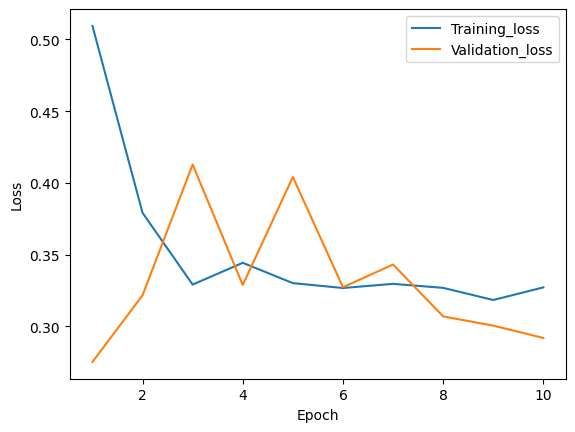

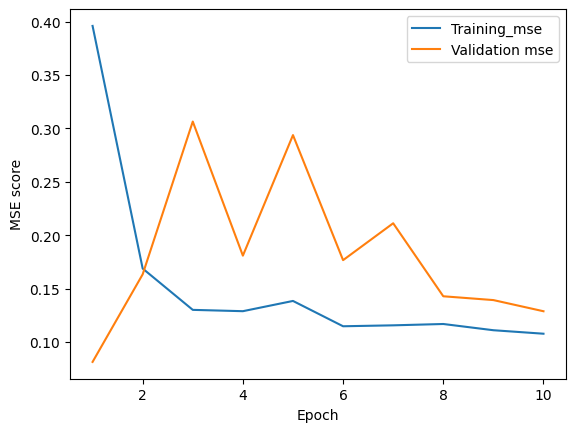

In [ ]:
#plotting to see if everything is consistent 
import matplotlib.pyplot as plt
import seaborn as sns

#Plot training and validation loss
num_epochs = 10
plt.plot(range(1, num_epochs+1 ), history.history['loss'], label = "Training_loss")
plt.plot (range(1, num_epochs + 1), history.history["val_loss"], label = "Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Plotting training and validation mse
plt.plot(range(1, num_epochs+1), history.history["mse"], label = "Training_mse")
plt.plot(range(1, num_epochs +1 ), history.history["val_mse"], label = "Validation mse")
plt.xlabel("Epoch")
plt.ylabel("MSE score")
plt.legend()
plt.show()

In [ ]:
#Evaluation on test set
loss, mae, mse = cnn_model.evaluate(X_test, y_test)


print("Loss is ", loss)
print("MSE is ", mse)
print("MAE IS ", mae)

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 390ms/step - loss: 0.2952 - mae: 0.2952 - mse: 0.1228
Loss is  0.2908563017845154
MSE is  0.2908563017845154
MAE IS  0.12084531038999557


In [ ]:
#Saving the model
cnn_model.save("my_cnn_model.h5")